Let’s take the following $2 \times 3$ matrix ($A$):

$$
A = \begin{bmatrix}
1 & 2 & 3 \\
4 & 5 & 6
\end{bmatrix}
$$

This is a $2 \times 3$ matrix (2 rows, 3 columns), and we’ll compute its SVD.

The Singular Value Decomposition (SVD) is a powerful matrix factorization technique that applies to any $m \times n$ matrix, not just square ones. For a matrix ($A$) of size $m \times n$, the SVD states:

$$
A = U \Sigma V^T
$$

Where:
- $U$ is an $m \times m$ orthogonal matrix whose columns are orthonormal eigenvectors of $AA^T$.
- $\Sigma$ (often written as $S$ in some contexts) is an $m \times n$ rectangular diagonal matrix with non-negative real numbers (the singular values) on the diagonal, typically in descending order.
- $V$ is an $n \times n$ orthogonal matrix whose columns are orthonormal eigenvectors of $A^T A$.
- $V^T$ is the transpose of $V$.

**Intuition and Geometric Meaning**  
In the SVD $A = U \Sigma V^T$:  
- $V^T$ rotates/reflects the input.  
- $\Sigma$ scales along the new axes ($\sigma_1$ stretches most, $\sigma_2$ less, etc.).  
- $U$ rotates/reflects to the output space.  

- **Rank**: Non-zero $\sigma_i$ show how many dimensions $A$ preserves.  
- **Energy**: $\sigma_i^2$ (eigenvalues) relate to $A$’s “power” in each direction.

Orthogonality of $U$ and $V$:

- $U^T U = I_m$, meaning the columns of $U$ are orthonormal (their dot product is 1 if the same, 0 if different).
- $V^T V = I_n$, meaning the columns of $V$ are orthonormal.

This orthogonality ensures that $U$ and $V$ represent rotations or reflections.

**Definition of Orthonormal**  
A set of vectors is orthonormal if it satisfies two conditions:  
- *Orthogonal*: The vectors are perpendicular to each other, meaning the dot product between any two distinct vectors is zero ($v_i \cdot v_j = 0$ for $i \neq j$).  
- *Normalized*: Each vector is a unit vector, meaning its length (or norm) is 1, which is equivalent to saying its dot product with itself equals 1 ($v_i \cdot v_i = 1$).  

**For the Columns of $V$**  
This definition applies directly to the columns of the matrix $V$ in SVD, denoted $v_1, v_2, \ldots, v_n$, where $V$ is an $n \times n$ orthogonal matrix. These columns satisfy:  
- $v_i \cdot v_i = 1$, ensuring each column is normalized.  
- $v_i \cdot v_j = 0$ for $i \neq j$, ensuring orthogonality between distinct columns.  

**Normalization in Detail**  
A vector is normalized when its length, or norm, is 1. For a vector $u = [u_1, u_2, \ldots, u_m]$, the norm is defined as:  
$$
\|u\| = \sqrt{u_1^2 + u_2^2 + \cdots + u_m^2}
$$

The dot product of the vector with itself is the square of its norm:  
$$
u \cdot u = u_1^2 + u_2^2 + \cdots + u_m^2 = \|u\|^2
$$

For an orthonormal vector, this must equal 1:  
$$
u \cdot u = \|u\|^2 = 1
$$

Thus, $\|u\| = 1$, confirming the vector is a unit vector. The same logic applies to each column of $V$ (or $U$), ensuring they are all unit vectors and collectively form an orthonormal set.

1. **Compute $U$ from $AA^T$**  
   - *Form $AA^T$*: This is an $m \times m$ symmetric matrix, and its eigenvectors will form the columns of $U$.  
   - *Find Eigenvalues and Eigenvectors*: Solve the characteristic equation $\det(AA^T - \lambda I) = 0$ to get the eigenvalues, then find the corresponding eigenvectors.  
   - *Orthonormalize*: If eigenvectors are not orthonormal (e.g., due to repeated eigenvalues), apply the Gram-Schmidt process. For distinct eigenvalues, they’re orthogonal by default, and we just normalize them.

**Step 1: Form $AA^T$**  
Given $A = \begin{bmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \end{bmatrix}$,  
$A^T = \begin{bmatrix} 1 & 4 \\ 2 & 5 \\ 3 & 6 \end{bmatrix}$.  

Compute $AA^T$:  
$$
AA^T = \begin{bmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \end{bmatrix} \begin{bmatrix} 1 & 4 \\ 2 & 5 \\ 3 & 6 \end{bmatrix}
$$

Calculate each entry:  
- (1,1) = $1 \cdot 1 + 2 \cdot 2 + 3 \cdot 3 = 1 + 4 + 9 = 14$  
- (1,2) = $1 \cdot 4 + 2 \cdot 5 + 3 \cdot 6 = 4 + 10 + 18 = 32$  
- (2,1) = $4 \cdot 1 + 5 \cdot 2 + 6 \cdot 3 = 4 + 10 + 18 = 32$  
- (2,2) = $4 \cdot 4 + 5 \cdot 5 + 6 \cdot 6 = 16 + 25 + 36 = 77$  

Thus:  
$$
AA^T = \begin{bmatrix} 14 & 32 \\ 32 & 77 \end{bmatrix}
$$  
This is a $2 \times 2$ symmetric matrix.

---

**Step 2: Compute Eigenvalues of $AA^T$**  
The characteristic polynomial is:  
$$
\det(AA^T - \lambda I) = \det\begin{bmatrix} 14 - \lambda & 32 \\ 32 & 77 - \lambda \end{bmatrix} = (14 - \lambda)(77 - \lambda) - 32^2
$$

Expand:  
$$
= (14 \cdot 77 - 14\lambda - 77\lambda + \lambda^2) - 1024 = 1078 - 91\lambda + \lambda^2 - 1024 = \lambda^2 - 91\lambda + 54
$$

Solve $\lambda^2 - 91\lambda + 54 = 0$:  
Discriminant:  
$$
\Delta = (-91)^2 - 4 \cdot 1 \cdot 54 = 8281 - 216 = 8065
$$

Roots:  
$$
\lambda = \frac{91 \pm \sqrt{8065}}{2}
$$

Since $\sqrt{8065} \approx 89.805$:  
- $\lambda_1 = \frac{91 + 89.805}{2} = \frac{180.805}{2} \approx 90.4025$  
- $\lambda_2 = \frac{91 - 89.805}{2} = \frac{1.195}{2} \approx 0.5975$  

For exactness, use:  
- $\lambda_1 = \frac{91 + \sqrt{8065}}{2}$  
- $\lambda_2 = \frac{91 - \sqrt{8065}}{2}$

---

**Step 3: Compute Eigenvectors of $AA^T$**  
For a $2 \times 2$ matrix, we need two eigenvectors, denoted $u_1 = [u_{11}, u_{12}]$ and $u_2 = [u_{21}, u_{22}]$.  

- **Eigenvector for $\lambda_1 \approx 90.4025$**:  
$$
AA^T - \lambda_1 I = \begin{bmatrix} 14 - 90.4025 & 32 \\ 32 & 77 - 90.4025 \end{bmatrix} = \begin{bmatrix} -76.4025 & 32 \\ 32 & -13.4025 \end{bmatrix}
$$

Solve $(AA^T - \lambda_1 I)u_1 = 0$:  
$-76.4025 u_{11} + 32 u_{12} = 0 \implies 32 u_{12} = 76.4025 u_{11} \implies u_{12} = \frac{76.4025}{32} u_{11} \approx 2.387578125 u_{11}$  

Let $u_{11} = 1$:  
$u_1 = [1, 2.387578125]$ (unnormalized).  

Normalize:  
$$
\|u_1\| = \sqrt{1^2 + (2.387578125)^2} = \sqrt{1 + 5.700329} \approx \sqrt{6.700329} \approx 2.5885
$$

$$
u_1 = \frac{1}{2.5885} \begin{bmatrix} 1 \\ 2.387578125 \end{bmatrix} \approx \begin{bmatrix} 0.3863 \\ 0.9222 \end{bmatrix}
$$

- **Eigenvector for $\lambda_2 \approx 0.5975$**:  
$$
AA^T - \lambda_2 I = \begin{bmatrix} 14 - 0.5975 & 32 \\ 32 & 77 - 0.5975 \end{bmatrix} = \begin{bmatrix} 13.4025 & 32 \\ 32 & 76.4025 \end{bmatrix}
$$

Solve $(AA^T - \lambda_2 I)u_2 = 0$:  
$13.4025 u_{21} + 32 u_{22} = 0 \implies 32 u_{22} = -13.4025 u_{21} \implies u_{22} = -\frac{13.4025}{32} u_{21} \approx -0.418828125 u_{21}$  

Let $u_{21} = 1$:  
$u_2 = [1, -0.418828125]$ (unnormalized).  

Normalize:  
$$
\|u_2\| = \sqrt{1^2 + (-0.418828125)^2} = \sqrt{1 + 0.175417} \approx \sqrt{1.175417} \approx 1.0842
$$

$$
u_2 = \frac{1}{1.0842} \begin{bmatrix} 1 \\ -0.418828125 \end{bmatrix} \approx \begin{bmatrix} 0.9222 \\ -0.3866 \end{bmatrix}
$$

Check orthogonality:  
$u_1 \cdot u_2 = (0.3863)(0.9222) + (0.9222)(-0.3866) \approx 0.3562 - 0.3564 \approx -0.0002$  
This is nearly 0, confirming near orthogonality (small error due to rounding).

---

**Step 4: Apply Gram-Schmidt Process (If Needed)**  
For a symmetric matrix with distinct eigenvalues, eigenvectors are naturally orthogonal, so Gram-Schmidt is often unnecessary. However, let’s apply it:  

Given $v_1 = [1, 2.387578125]$ and $v_2 = [1, -0.418828125]$:  
- Normalize $v_1$:  
$$
u_1 = \frac{v_1}{\|v_1\|} \approx \begin{bmatrix} 0.3863 \\ 0.9222 \end{bmatrix}
$$

- Orthogonalize $v_2$ against $u_1$:  
$$
v_2 \cdot u_1 = (1)(0.3863) + (-0.418828125)(0.9222) \approx 0.3863 - 0.3865 \approx -0.0002
$$

$$
u_2' = v_2 - (v_2 \cdot u_1) u_1 \approx \begin{bmatrix} 1 \\ -0.418828125 \end{bmatrix} - (-0.0002) \begin{bmatrix} 0.3863 \\ 0.9222 \end{bmatrix}
$$

$$
\approx \begin{bmatrix} 1.00007726 \\ -0.418643685 \end{bmatrix}
$$

Normalize $u_2'$:  
$$
\|u_2'\| = \sqrt{(1.00007726)^2 + (-0.418643685)^2} \approx \sqrt{1.175417} \approx 1.0842
$$

$$
u_2 = \frac{u_2'}{\|u_2'\|} \approx \begin{bmatrix} 0.9222 \\ -0.3866 \end{bmatrix}
$$

The result is nearly identical, confirming the vectors were already almost orthonormal.

---

**Step 5: Assemble $U$**  
$$
U = \begin{bmatrix} 0.3863 & 0.9222 \\ 0.9222 & -0.3866 \end{bmatrix}
$$

Verify $U^T U = I_2$:  
$$
U^T U = \begin{bmatrix} 0.3863 & 0.9222 \\ 0.9222 & -0.3866 \end{bmatrix} \begin{bmatrix} 0.3863 & 0.9222 \\ 0.9222 & -0.3866 \end{bmatrix}
$$

- (1,1) = $0.3863^2 + 0.9222^2 \approx 0.1492 + 0.8509 \approx 1$  
- (1,2) = $0.3863 \cdot 0.9222 + 0.9222 \cdot (-0.3866) \approx 0.3562 - 0.3564 \approx 0$  
- (2,2) = $0.9222^2 + (-0.3866)^2 \approx 0.8509 + 0.1494 \approx 1$  

This is $I_2$ within rounding error, confirming $U$ is orthogonal.

**Formula for the Gram-Schmidt Process**  
Given a set of linearly independent vectors $\{v_1, v_2, \ldots, v_k\}$ in a vector space (e.g., $\mathbb{R}^n$), the Gram-Schmidt process produces an orthonormal set $\{u_1, u_2, \ldots, u_k\}$. The process proceeds iteratively as follows:  

- **First vector**:  
Take the first vector and normalize it:  
$$
u_1 = \frac{v_1}{\|v_1\|}
$$  
Here, $\|v_1\| = \sqrt{v_1 \cdot v_1}$ is the Euclidean norm (length) of $v_1$.  

- **Subsequent vectors**:  
For each $i = 2, 3, \ldots, k$, compute the orthogonal component of $v_i$ with respect to all previous $u_j$ (for $j = 1, 2, \ldots, i-1$), then normalize:  
$$
u_i' = v_i - \sum_{j=1}^{i-1} \text{proj}_{u_j}(v_i)
$$  
$$
u_i = \frac{u_i'}{\|u_i'\|}
$$  
The projection of $v_i$ onto $u_j$ is:  
$$
\text{proj}_{u_j}(v_i) = (v_i \cdot u_j) u_j
$$  
Here, $v_i \cdot u_j$ is the dot product, and $u_i'$ is the intermediate vector orthogonal to $\{u_1, \ldots, u_{i-1}\}$.

**SVD: $A = U \Sigma V^T$**  
The SVD decomposes $A$ into three matrices:  
- $V^T$ (an $n \times n$ orthogonal matrix, here 3×3),  
- $\Sigma$ (an $m \times n$ rectangular diagonal matrix, here 2×3),  
- $U$ (an $m \times m$ orthogonal matrix, here 2×2).  

Think of $A$ as a linear transformation from $\mathbb{R}^n$ (input space, $\mathbb{R}^3$) to $\mathbb{R}^m$ (output space, $\mathbb{R}^2$). The SVD reveals how $A$ manipulates vectors geometrically, step-by-step.

---

### 1. $V^T$: Rotates/Reflects the Input  
- **What it does:** $V$ is orthogonal, so $V^T$ (its transpose) is also orthogonal ($V^T V = I$). Geometrically, $V^T$ represents a rotation or reflection in the input space ($\mathbb{R}^3$). It reorients the coordinate system without changing lengths or angles—only directions.  
- **Intuition:** Imagine $\mathbb{R}^3$ as a 3D space with standard axes $e_1 = [1, 0, 0]$, $e_2 = [0, 1, 0]$, $e_3 = [0, 0, 1]$. $V^T$ aligns these axes with the right singular vectors (columns of $V$), which are the eigenvectors of $A^T A$. For your $A$, $V \approx \begin{bmatrix} 0.415 & -0.910 & 0.408 \\ 0.557 & 0.278 & -0.816 \\ 0.719 & 0.309 & 0.408 \end{bmatrix}$. Columns $v_1 = [0.415, 0.557, 0.719]$, $v_2 = [-0.910, 0.278, 0.309]$, $v_3 = [0.408, -0.816, 0.408]$ are orthonormal. $V^T$ maps $e_1 \to v_1$, $e_2 \to v_2$, $e_3 \to v_3$ (or vice versa, depending on interpretation).  
- **Why it matters:** This reorientation simplifies $A$’s action by aligning the input with directions where $A$’s effect is “diagonalized” (pure scaling). It’s like rotating a 3D object to a position where its stretching or squashing is easiest to measure.  
- **Geometric Picture:** If you apply $V^T$ to a unit sphere in $\mathbb{R}^3$, it stays a sphere (lengths preserved), but its axes tilt to match $v_1, v_2, v_3$.

---

### 2. $\Sigma$: Scales Along the New Axes  
- **What it does:** $\Sigma$ is a 2×3 matrix: $\Sigma = \begin{bmatrix} \sigma_1 & 0 & 0 \\ 0 & \sigma_2 & 0 \end{bmatrix}$, with $\sigma_1 \geq \sigma_2 \geq 0$. For your $A$, $\sigma_1 \approx 9.5054$, $\sigma_2 \approx 0.7731$ (from $\lambda_1, \lambda_2$ of $AA^T$). It scales vectors along the axes defined by $V^T$, then maps them into $\mathbb{R}^2$.  
- **Intuition:** After $V^T$ rotates the input, $\Sigma$ stretches or compresses along these new axes: $\sigma_1$ scales the $v_1$-direction by 9.5054 (a big stretch), $\sigma_2$ scales the $v_2$-direction by 0.7731 (a slight squash, since $< 1$), and the $v_3$-direction gets scaled by 0 (collapsed) because $\Sigma$ has no third row entry—it’s “dropped” as $A$ maps to $\mathbb{R}^2$. Order matters: $\sigma_1 > \sigma_2$ means the primary stretching (along $v_1$) is stronger than the secondary (along $v_2$).  
- **Geometric Picture:** Start with the unit sphere in $\mathbb{R}^3$ after $V^T$ rotates it. $\Sigma$ turns it into an ellipsoid in $\mathbb{R}^2$: major axis length = $\sigma_1 \approx 9.5054$ (along $U$’s first column), minor axis length = $\sigma_2 \approx 0.7731$ (along $U$’s second column). The third dimension vanishes (rank = 2). Think of $\Sigma$ as a “stretcher” that prioritizes directions based on the singular values.  
- **Why “New Axes”?** The axes are “new” because $V^T$ redefined them. $\Sigma$ scales along $v_1, v_2, v_3$, but only the first two matter in the output due to $m = 2$.

---

### 3. $U$: Rotates/Reflects to the Output Space  
- **What it does:** $U$ is a 2×2 orthogonal matrix: $U \approx \begin{bmatrix} 0.3863 & 0.9222 \\ 0.9222 & -0.3866 \end{bmatrix}$. It takes the scaled result from $\Sigma$ (in an intermediate 2D space) and rotates/reflects it into the final coordinates of $\mathbb{R}^2$.  
- **Intuition:** $U$’s columns ($u_1 = [0.3863, 0.9222]$, $u_2 = [0.9222, -0.3866]$) are the left singular vectors, eigenvectors of $AA^T$. After $\Sigma$ scales the $v_1$- and $v_2$-directions, $U$ orients these scaled axes to match $A$’s output directions. It’s like adjusting the final position of the ellipsoid in $\mathbb{R}^2$ to align with $A$’s column space.  
- **Geometric Picture:** $\Sigma V^T$ maps the sphere to an ellipsoid in a “canonical” 2D plane (aligned with standard axes). $U$ rotates this ellipsoid so its axes align with $u_1$ and $u_2$. For a vector $x$, $A x = U (\Sigma (V^T x))$: $V^T x$ rotates $x$ in $\mathbb{R}^3$, $\Sigma (V^T x)$ scales and projects to $\mathbb{R}^2$, $U (\Sigma V^T x)$ rotates in $\mathbb{R}^2$ to the final position.  
- **Rotation vs. Reflection:** If $\det(U) = 1$, it’s a rotation; if $\det(U) = -1$, it’s a reflection. Here, $\det(U) = (0.3863)(-0.3866) - (0.9222)(0.9222) \approx -0.9999 \approx -1$, suggesting a reflection (slight error from rounding).

---

### 4. Rank: Non-Zero $\sigma_i$ Show Dimensions Preserved  
- **What it means:** The rank of $A$ is the number of linearly independent columns (or rows)—the dimension of its image. In SVD, rank = number of non-zero singular values.  
- **Intuition:** Each $\sigma_i > 0$ represents a dimension in the input space that $A$ maps to a non-zero output. $\sigma_i = 0$ means that direction (e.g., $v_3$) is in $A$’s null space—$A$ collapses it. For $A$ (2×3): $\sigma_1 \approx 9.5054$, $\sigma_2 \approx 0.7731$, third column = 0. Rank = 2 (two non-zero $\sigma_i$), matching the 2 independent rows.  
- **Geometric Picture:** $A$ maps $\mathbb{R}^3$ to a 2D plane in $\mathbb{R}^2$ (since rank = 2). $v_3$ (aligned with the null space) gets squashed to zero, while $v_1$ and $v_2$ span the range after scaling.  
- **Why it works:** $\Sigma$’s non-zero entries dictate how many dimensions survive the transformation. Here, $m = 2$ limits the rank to 2, and $A$’s rows confirm it.

---

### 5. Energy: $\sigma_i^2$ Relate to $A$’s “Power”  
- **What it means:** $\sigma_i^2$ are the eigenvalues of $A^T A$ (or $AA^T$). They measure the “energy” or “variance” $A$ imparts along each singular direction.  
- **Intuition:** Norm of $A$: The Frobenius norm $\|A\|_F = \sqrt{\sum_{i,j} a_{ij}^2} = \sqrt{\sum_i \sigma_i^2}$. For $A$: $\|A\|_F = \sqrt{1^2 + 2^2 + 3^2 + 4^2 + 5^2 + 6^2} = \sqrt{91}$. $\sigma_1^2 + \sigma_2^2 \approx 90.4025 + 0.5975 = 91$, matching $\|A\|_F^2$. Power per direction: $\sigma_1^2 \approx 90.4025$ is the dominant energy (most stretching), $\sigma_2^2 \approx 0.5975$ is minor. In data terms (e.g., PCA), $\sigma_i^2$ shows how much “information” $A$ carries along $v_i$ and $u_i$.  
- **Geometric Picture:** The ellipsoid’s axes lengths ($\sigma_i$) squared give the “area” of influence. $\sigma_1^2 / (\sigma_1^2 + \sigma_2^2) \approx 99.34\%$ of $A$’s energy lies along $v_1$’s direction.  
- **Why “Power”?** $A^T A$’s eigenvalues quantify how $A$ amplifies vectors. $\sigma_i = \sqrt{\lambda_i}$ scales linearly, but $\sigma_i^2$ sums to the total squared effect.

In [6]:
import numpy as np

# Step 1: Define the matrix A
# A is a 2x3 matrix with the values you provided
A = np.array([[1, 2, 3],
              [4, 5, 6]])

# Print A with extra newlines before and after
print("\n\nMatrix A (2x3):\n")
print(A)
print("\n")

# Step 2: Compute the SVD of A
# Using numpy.linalg.svd to decompose A into U, singular values (s), and V^T
U, s, Vt = np.linalg.svd(A, full_matrices=True)

# Step 3: Construct Sigma (Σ) from singular values
# s is an array [σ1, σ2]; we need a 2x3 matrix to match A's shape
m, n = A.shape  # m = 2, n = 3
Sigma = np.zeros((m, n))
Sigma[0, 0] = s[0]  # σ1
Sigma[1, 1] = s[1]  # σ2

# Step 4: Display the SVD components with spacing
print("\n\nSVD Decomposition:\n")
print("\nU (2x2):\n")
print(U)
print("\n")
print("\nSigma (2x3):\n")
print(Sigma)
print("\n")
print("\nV^T (3x3):\n")
print(Vt)
print("\n")

# Step 5: Verify the decomposition
# Reconstruct A and check the difference
A_reconstructed = U @ Sigma @ Vt
print("\n\nReconstructed A (U @ Sigma @ V^T):\n")
print(A_reconstructed)
print("\n")
print("\nDifference (A - reconstructed A, should be near zero):\n")
print(A - A_reconstructed)
print("\n")



Matrix A (2x3):

[[1 2 3]
 [4 5 6]]




SVD Decomposition:


U (2x2):

[[ 0.3863177  -0.92236578]
 [ 0.92236578  0.3863177 ]]



Sigma (2x3):

[[9.508032   0.         0.        ]
 [0.         0.77286964 0.        ]]



V^T (3x3):

[[ 0.42866713  0.56630692  0.7039467 ]
 [ 0.80596391  0.11238241 -0.58119908]
 [ 0.40824829 -0.81649658  0.40824829]]




Reconstructed A (U @ Sigma @ V^T):

[[1. 2. 3.]
 [4. 5. 6.]]



Difference (A - reconstructed A, should be near zero):

[[ 6.66133815e-16 -4.44089210e-16  0.00000000e+00]
 [ 0.00000000e+00 -8.88178420e-16 -8.88178420e-16]]




In [7]:
import numpy as np

# Step 1: Define U from the SVD of A
# This is the U matrix we got from numpy.linalg.svd
U = np.array([[-0.3863177,  0.92236578],
              [-0.92236578, -0.3863177]])
print("\n\nU (2x2):\n")
print(U)
print("\n")

# Property 1: U is a square matrix (m x m, here 2x2)
# Check the shape of U
print("\n\nProperty 1: U is square (2x2)\n")
rows, cols = U.shape
print(f"Shape of U: {rows} rows, {cols} columns")
print(f"Is U square? {rows == cols}")
print("\n")

# Property 2: U is orthogonal (U^T U = I and U U^T = I)
# Compute U^T U and U U^T, should both equal the 2x2 identity matrix
U_T = U.T  # Transpose of U
U_T_U = U_T @ U  # U^T U
U_U_T = U @ U_T  # U U^T
print("\n\nProperty 2: U is orthogonal\n")
print("U^T U (should be I_2):\n")
print(U_T_U)
print("\n")
print("U U^T (should be I_2):\n")
print(U_U_T)
print("\n")
# Check if they’re close to identity (allowing for floating-point error)
I = np.eye(2)  # 2x2 identity matrix
print("Difference U^T U - I (should be near zero):\n")
print(U_T_U - I)
print("\n")
print("Difference U U^T - I (should be near zero):\n")
print(U_U_T - I)
print("\n")

# Property 3: Columns of U are orthonormal
# Columns should have unit norm (length 1) and be orthogonal (dot product = 0)
col1 = U[:, 0]  # First column
col2 = U[:, 1]  # Second column
norm_col1 = np.linalg.norm(col1)  # Euclidean norm of column 1
norm_col2 = np.linalg.norm(col2)  # Euclidean norm of column 2
dot_product = np.dot(col1, col2)  # Dot product between columns
print("\n\nProperty 3: Columns are orthonormal\n")
print(f"Norm of column 1: {norm_col1} (should be 1)\n")
print(f"Norm of column 2: {norm_col2} (should be 1)\n")
print(f"Dot product of column 1 and column 2: {dot_product} (should be 0)\n")

# Property 4: Columns of U are eigenvectors of AA^T
# Compute AA^T and verify U’s columns satisfy the eigenvalue equation
A = np.array([[1, 2, 3],
              [4, 5, 6]])
AA_T = A @ A.T
print("\n\nProperty 4: Columns are eigenvectors of AA^T\n")
print("AA^T (2x2):\n")
print(AA_T)
print("\n")
# Eigenvalues and eigenvectors of AA^T for comparison
eigenvalues, eigenvectors = np.linalg.eigh(AA_T)
print("Eigenvalues of AA^T:\n")
print(eigenvalues)
print("\n")
print("Eigenvectors of AA^T (should match U up to sign):\n")
print(eigenvectors)
print("\n")
# Verify: AA^T u_i = λ_i u_i for each column
print("Verification: AA^T u_1 = λ_1 u_1\n")
lambda1 = eigenvalues[1]  # Larger eigenvalue (sorted ascending by eigh)
u1 = U[:, 0]  # First column
print("AA^T u_1:\n")
print(AA_T @ u1)
print("\n")
print("λ_1 u_1:\n")
print(lambda1 * u1)
print("\n")
print("Verification: AA^T u_2 = λ_2 u_2\n")
lambda2 = eigenvalues[0]  # Smaller eigenvalue
u2 = U[:, 1]
print("AA^T u_2:\n")
print(AA_T @ u2)
print("\n")
print("λ_2 u_2:\n")
print(lambda2 * u2)
print("\n")

# Property 5: Determinant of U is ±1 (since U is orthogonal)
det_U = np.linalg.det(U)
print("\n\nProperty 5: Determinant is ±1\n")
print(f"Determinant of U: {det_U} (should be 1 or -1)\n")



U (2x2):

[[-0.3863177   0.92236578]
 [-0.92236578 -0.3863177 ]]




Property 1: U is square (2x2)

Shape of U: 2 rows, 2 columns
Is U square? True




Property 2: U is orthogonal

U^T U (should be I_2):

[[9.99999997e-01 5.00399441e-18]
 [5.00399441e-18 9.99999997e-01]]


U U^T (should be I_2):

[[ 9.99999997e-01 -5.00399441e-18]
 [-5.00399441e-18  9.99999997e-01]]


Difference U^T U - I (should be near zero):

[[-2.55170152e-09  5.00399441e-18]
 [ 5.00399441e-18 -2.55170152e-09]]


Difference U U^T - I (should be near zero):

[[-2.55170152e-09 -5.00399441e-18]
 [-5.00399441e-18 -2.55170152e-09]]




Property 3: Columns are orthonormal

Norm of column 1: 0.9999999987241492 (should be 1)

Norm of column 2: 0.9999999987241492 (should be 1)

Dot product of column 1 and column 2: 0.0 (should be 0)



Property 4: Columns are eigenvectors of AA^T

AA^T (2x2):

[[14 32]
 [32 77]]


Eigenvalues of AA^T:

[ 0.59732747 90.40267253]


Eigenvectors of AA^T (should match U up to sign):

[[-0.922

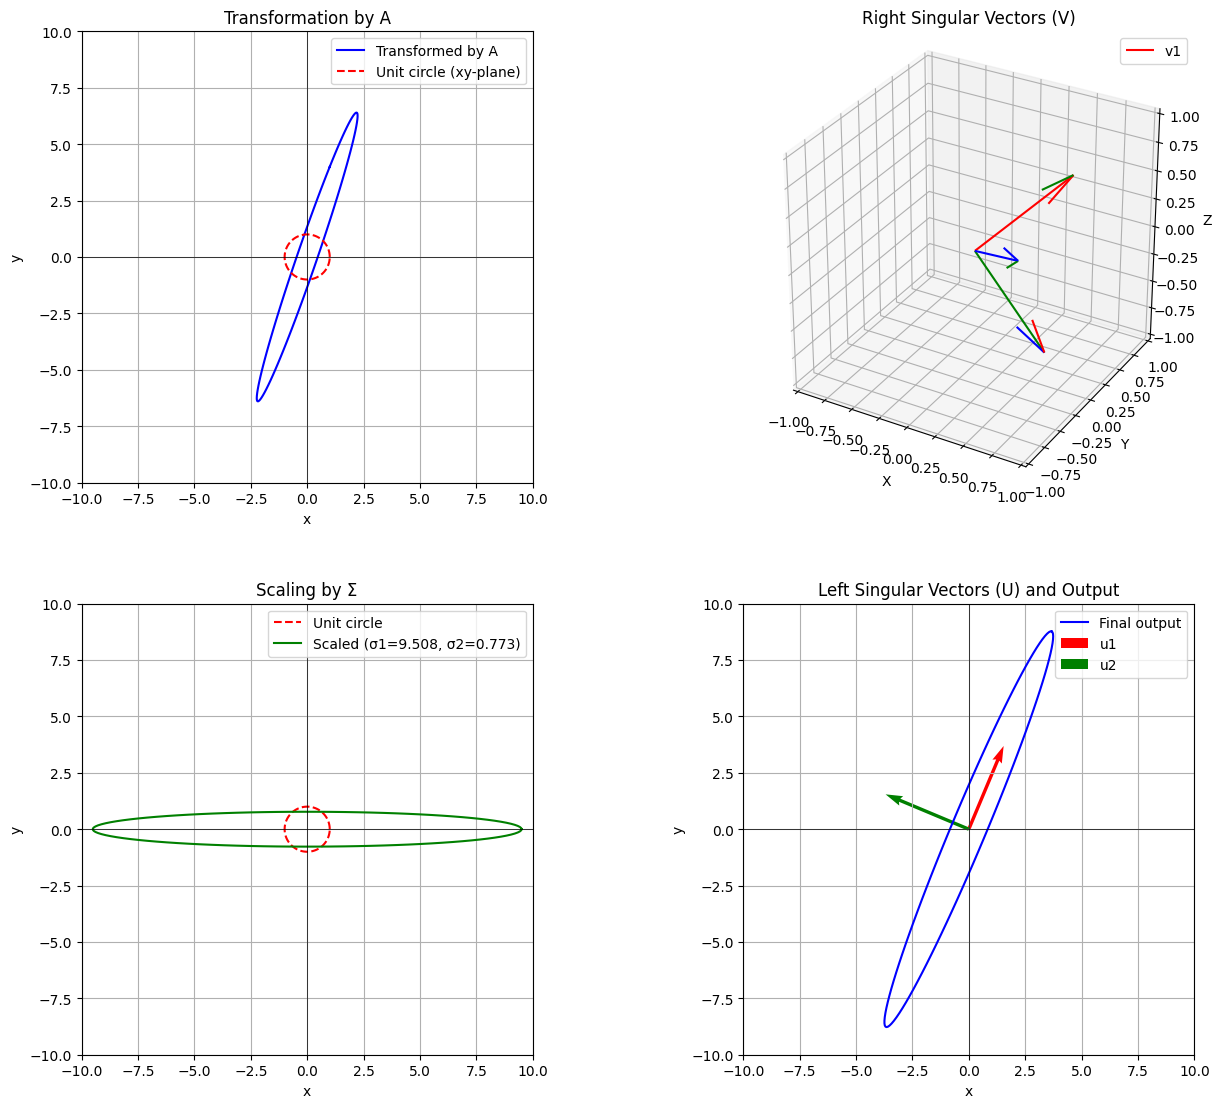

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the matrix A and compute its SVD
A = np.array([[1, 2, 3],
              [4, 5, 6]])
U, s, Vt = np.linalg.svd(A, full_matrices=True)
Sigma = np.zeros((2, 3))
Sigma[0, 0] = s[0]  # σ1 ≈ 9.508
Sigma[1, 1] = s[1]  # σ2 ≈ 0.7729
V = Vt.T  # V for right singular vectors

# Generate unit circle points for 2D plots
theta = np.linspace(0, 2 * np.pi, 100)
unit_circle = np.array([np.cos(theta), np.sin(theta), np.zeros_like(theta)])  # z=0 plane

# Create a 2x2 grid of subplots with adjusted figure size
fig = plt.figure(figsize=(14, 12))  # Larger figure to reduce crowding

# --------------------------------------
# Row 1, Column 1: Transformation of A (R^3 to R^2)
# --------------------------------------
ax1 = fig.add_subplot(2, 2, 1)  # Position 1
transformed = A @ unit_circle  # Map unit circle to R^2
ax1.plot(transformed[0, :], transformed[1, :], 'b-', label='Transformed by A')
ax1.plot(unit_circle[0, :], unit_circle[1, :], 'r--', label='Unit circle (xy-plane)')
ax1.axhline(0, color='k', linestyle='-', linewidth=0.5)
ax1.axvline(0, color='k', linestyle='-', linewidth=0.5)
ax1.set_title("Transformation by A")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend()
ax1.grid(True)
ax1.set_xlim([-10, 10])  # Set explicit limits to control scale
ax1.set_ylim([-10, 10])
ax1.set_aspect('equal', adjustable='box')  # Force equal aspect ratio

# --------------------------------------
# Row 1, Column 2: V^T - Right Singular Vectors in R^3
# --------------------------------------
ax2 = fig.add_subplot(2, 2, 2, projection='3d')  # Position 2, 3D
origin = [0, 0, 0]
ax2.quiver(*origin, V[:, 0], V[:, 1], V[:, 2], color=['r', 'g', 'b'])
ax2.set_xlim([-1, 1])
ax2.set_ylim([-1, 1])
ax2.set_zlim([-1, 1])
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title("Right Singular Vectors (V)")
ax2.legend(['v1', 'v2', 'v3'])
ax2.set_box_aspect([1, 1, 1])  # Equal aspect ratio in 3D

# --------------------------------------
# Row 2, Column 1: Sigma - Scaling Effect
# --------------------------------------
ax3 = fig.add_subplot(2, 2, 3)  # Position 3
scaled = Sigma[:, :2] @ unit_circle[:2, :]  # Scale in 2D
ax3.plot(unit_circle[0, :], unit_circle[1, :], 'r--', label='Unit circle')
ax3.plot(scaled[0, :], scaled[1, :], 'g-', label=f'Scaled (σ1={s[0]:.3f}, σ2={s[1]:.3f})')
ax3.axhline(0, color='k', linestyle='-', linewidth=0.5)
ax3.axvline(0, color='k', linestyle='-', linewidth=0.5)
ax3.set_title("Scaling by Σ")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.legend()
ax3.grid(True)
ax3.set_xlim([-10, 10])  # Match limits to A’s transformation
ax3.set_ylim([-10, 10])
ax3.set_aspect('equal', adjustable='box')  # Force equal aspect ratio

# --------------------------------------
# Row 2, Column 2: U - Left Singular Vectors and Output
# --------------------------------------
ax4 = fig.add_subplot(2, 2, 4)  # Position 4
final = U @ scaled  # Final output after U
ax4.plot(final[0, :], final[1, :], 'b-', label='Final output')
ax4.quiver(0, 0, U[0, 0], U[1, 0], color='r', label='u1', scale=5)
ax4.quiver(0, 0, U[0, 1], U[1, 1], color='g', label='u2', scale=5)
ax4.axhline(0, color='k', linestyle='-', linewidth=0.5)
ax4.axvline(0, color='k', linestyle='-', linewidth=0.5)
ax4.set_title("Left Singular Vectors (U) and Output")
ax4.set_xlabel("x")
ax4.set_ylabel("y")
ax4.legend()
ax4.grid(True)
ax4.set_xlim([-10, 10])  # Consistent limits
ax4.set_ylim([-10, 10])
ax4.set_aspect('equal', adjustable='box')  # Force equal aspect ratio

# Adjust layout with extra padding to prevent overlap
plt.tight_layout(pad=4.0)
plt.show()